In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
raw_dir = Path("../data/raw")
list(raw_dir.iterdir())

[PosixPath('../data/raw/.DS_Store'),
 PosixPath('../data/raw/data2.csv'),
 PosixPath('../data/raw/data1.csv'),
 PosixPath('../data/raw/archive (1).zip')]

In [3]:
csv_path = raw_dir / "data1.csv"
csv_path

PosixPath('../data/raw/data1.csv')

In [5]:
sample = pd.read_csv(csv_path, nrows=10)
sample

,GridID,TimeInterval,countrycode,smsin,smsout,callin,callout,internet
0,1,1383260400000,0,0.081363,NaN,NaN,NaN,NaN
1,1,1383260400000,39,0.141864,0.156787,0.160938,0.052275,11.028366
2,1,1383261000000,0,0.136588,NaN,NaN,0.027300,NaN
3,1,1383261000000,33,NaN,NaN,NaN,NaN,0.026137
4,1,1383261000000,39,0.278452,0.119926,0.188777,0.133637,11.100963
5,1,1383261600000,0,0.053438,NaN,NaN,NaN,NaN
6,1,1383261600000,39,0.330641,0.170952,0.134176,0.054601,10.892771
7,1,1383262200000,0,0.026137,NaN,NaN,NaN,NaN
8,1,1383262200000,39,0.681434,0.220815,0.027300,0.053438,8.622425
9,1,1383262800000,0,0.027300,NaN,NaN,NaN,NaN


In [6]:
sample.columns.tolist()

['GridID',
 'TimeInterval',
 'countrycode',
 'smsin',
 'smsout',
 'callin',
 'callout',
 'internet']

In [7]:
sample.dtypes

GridID            int64
TimeInterval      int64
countrycode       int64
smsin           float64
smsout          float64
callin          float64
callout         float64
internet        float64
dtype: object

In [9]:
csv_path = Path("../data/raw/data1.csv")
processed_path = Path("../data/processed/internet_by_grid_time.parquet")

usecols = ["GridID", "TimeInterval", "internet"]

chunks = []
chunk_size = 1_000_000

for i, chunk in enumerate(pd.read_csv(csv_path, usecols=usecols, chunksize=chunk_size)):
    print(f"Processing chunk {i}...")
    chunk["internet"] = chunk["internet"].fillna(0)
    grouped = (
        chunk.groupby(["GridID", "TimeInterval"], as_index=False)["internet"]
        .sum()
    )
    chunks.append(grouped)

df = pd.concat(chunks, ignore_index=True)

df = (
    df.groupby(["GridID", "TimeInterval"], as_index=False)["internet"]
    .sum()
)

df["datetime"] = pd.to_datetime(df["TimeInterval"], unit="ms")

df.to_parquet(processed_path, index=False)

df.head()

Processing chunk 0...
Processing chunk 1...
Processing chunk 2...
Processing chunk 3...
Processing chunk 4...
Processing chunk 5...
Processing chunk 6...
Processing chunk 7...
Processing chunk 8...
Processing chunk 9...
Processing chunk 10...
Processing chunk 11...
Processing chunk 12...
Processing chunk 13...
Processing chunk 14...
Processing chunk 15...
Processing chunk 16...
Processing chunk 17...
Processing chunk 18...
Processing chunk 19...
Processing chunk 20...
Processing chunk 21...
Processing chunk 22...
Processing chunk 23...
Processing chunk 24...
Processing chunk 25...
Processing chunk 26...
Processing chunk 27...
Processing chunk 28...
Processing chunk 29...
Processing chunk 30...
Processing chunk 31...
Processing chunk 32...
Processing chunk 33...
Processing chunk 34...
Processing chunk 35...
Processing chunk 36...
Processing chunk 37...
Processing chunk 38...
Processing chunk 39...
Processing chunk 40...
Processing chunk 41...
Processing chunk 42...
Processing chunk 43..

,GridID,TimeInterval,internet,datetime
0,1,1383260400000,11.028366,2013-10-31 23:00:00
1,1,1383261000000,11.127101,2013-10-31 23:10:00
2,1,1383261600000,10.892771,2013-10-31 23:20:00
3,1,1383262200000,8.622425,2013-10-31 23:30:00
4,1,1383262800000,8.009927,2013-10-31 23:40:00


In [10]:
#verify that the parquet file can be read correctly
df = pd.read_parquet("../data/processed/internet_by_grid_time.parquet")
df.head()

,GridID,TimeInterval,internet,datetime
0,1,1383260400000,11.028366,2013-10-31 23:00:00
1,1,1383261000000,11.127101,2013-10-31 23:10:00
2,1,1383261600000,10.892771,2013-10-31 23:20:00
3,1,1383262200000,8.622425,2013-10-31 23:30:00
4,1,1383262800000,8.009927,2013-10-31 23:40:00


In [11]:
#find the top 20 grids with the highest total internet usage
top_grids = (
    df.groupby("GridID")["internet"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_grids

GridID
5161    6.329188e+06
5059    5.834589e+06
5259    5.759423e+06
5061    5.019714e+06
4459    4.955057e+06
5258    4.905377e+06
4855    4.660132e+06
5758    4.616881e+06
5159    4.597919e+06
6064    4.577781e+06
4856    4.548834e+06
4956    4.504520e+06
6058    4.408099e+06
5857    4.210446e+06
5262    4.198299e+06
4857    3.951505e+06
4955    3.949287e+06
5256    3.937371e+06
4961    3.889279e+06
4755    3.841104e+06
Name: internet, dtype: float64

In [12]:
#get the grid ID of the top grid
grid_id = top_grids.index[0]
grid_id

np.int64(5161)

In [13]:
#get the time series of internet usage for the top grid
ts = (
    df[df["GridID"] == grid_id]
    .sort_values("datetime")
    .set_index("datetime")["internet"]
)

ts.head(), ts.tail(), len(ts)

(datetime
 2013-10-31 23:00:00    379.972929
 2013-10-31 23:10:00    371.122713
 2013-10-31 23:20:00    429.297911
 2013-10-31 23:30:00    350.184224
 2013-10-31 23:40:00    268.586832
 Name: internet, dtype: float64,
 datetime
 2013-11-30 22:10:00     746.626246
 2013-11-30 22:20:00    1010.870908
 2013-11-30 22:30:00     725.152290
 2013-11-30 22:40:00     751.828005
 2013-11-30 22:50:00     621.147633
 Name: internet, dtype: float64,
 4320)

In [14]:
# check the frequency of the time series
ts.index.to_series().diff().value_counts().head()

datetime
0 days 00:10:00    4319
Name: count, dtype: int64

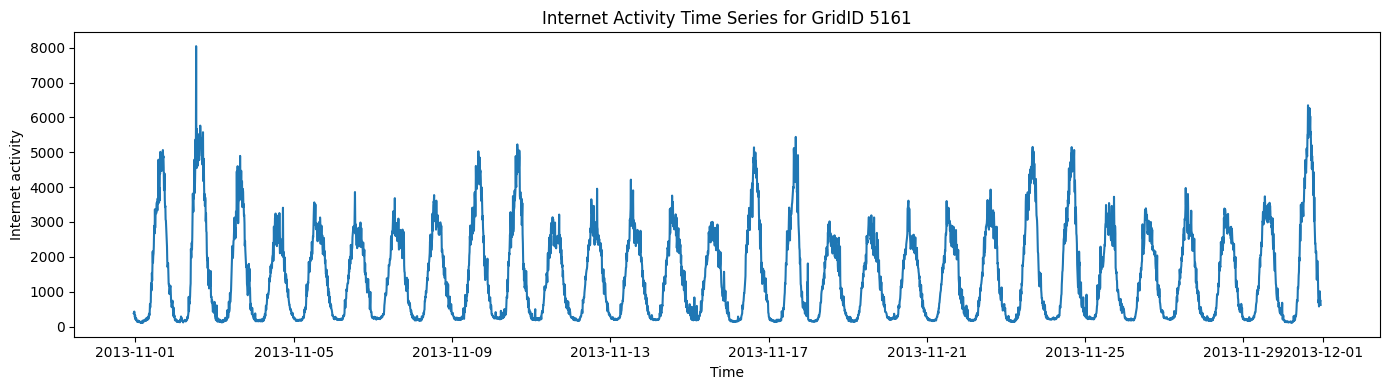

In [15]:
#plot the time series by datetime
plt.figure(figsize=(14,4))
plt.plot(ts.index, ts.values)
plt.title(f"Internet Activity Time Series for GridID {grid_id}")
plt.xlabel("Time")
plt.ylabel("Internet activity")
plt.tight_layout()
plt.show()

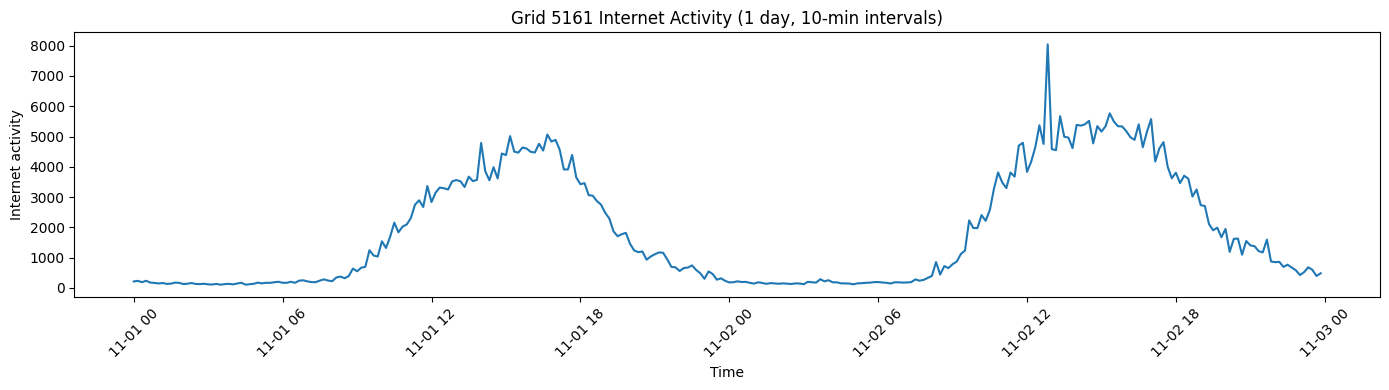

In [19]:
ts_day = ts.loc["2013-11-01":"2013-11-02"]

plt.figure(figsize=(14,4))
plt.plot(ts_day.index, ts_day.values)
plt.title(f"Grid {grid_id} Internet Activity (1 day, 10-min intervals)")
plt.xlabel("Time")
plt.ylabel("Internet activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

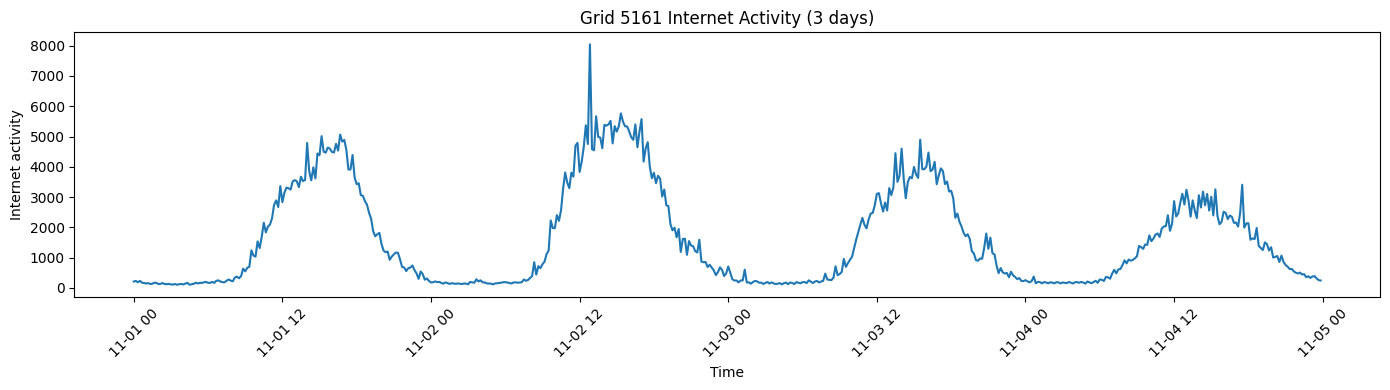

In [20]:
ts_3days = ts.loc["2013-11-01":"2013-11-04"]

plt.figure(figsize=(14,4))
plt.plot(ts_3days.index, ts_3days.values)
plt.title(f"Grid {grid_id} Internet Activity (3 days)")
plt.xlabel("Time")
plt.ylabel("Internet activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

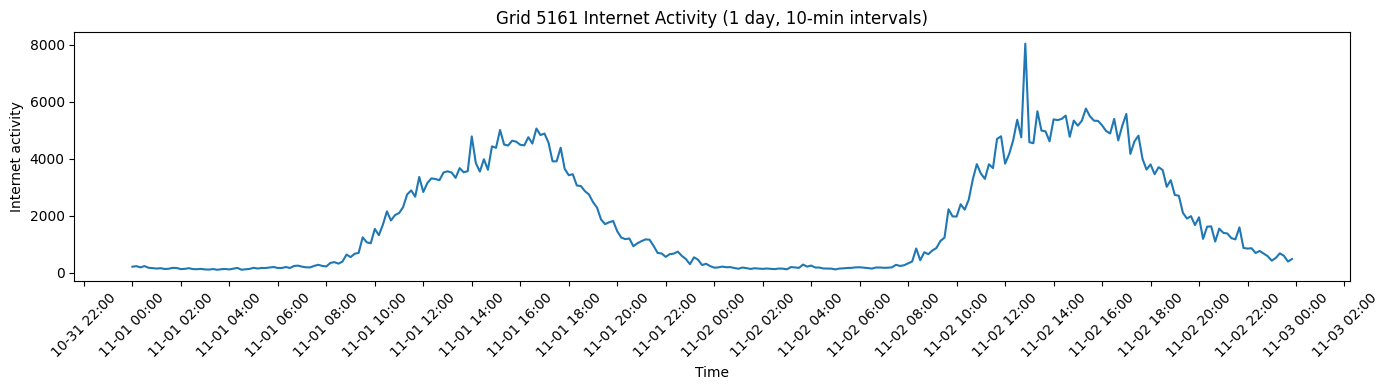

In [21]:
import matplotlib.dates as mdates

ts_day = ts.loc["2013-11-01":"2013-11-02"]

plt.figure(figsize=(14,4))
plt.plot(ts_day.index, ts_day.values)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))   # tick every 2 hours
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

plt.title(f"Grid {grid_id} Internet Activity (1 day, 10-min intervals)")
plt.xlabel("Time")
plt.ylabel("Internet activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()